In [ ]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import numpy as np 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cmocean as cmo
import matplotlib.dates as mdates
import os 
import xarray as xr 
import datetime
from datetime import datetime, timedelta


# ds = xr.open_dataset("hydro.nc", decode_times=False)
# print(ds)
# nt = len(ds.time) - 1
# z = ds.z.values

# # ds = ds.isel(time=slice(15, nt))

# nt = len(ds.time) - 1

# # Load adv data
# adv = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/data/usgs/eps_shear_tke.csv", parse_dates=['time'], index_col='time')
# adv.dropna(inplace=True, how='all')
# print(adv)
def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


Index(['eps', 'shear', 'uu_turb', 'vv_turb', 'ww_turb', 'uw_turb', 'vw_turb',
       'uv_turb', 'uu_wave', 'vv_wave', 'ww_wave', 'uw_wave', 'vw_wave',
       'uv_wave', 'smoothed_shear'],
      dtype='str')


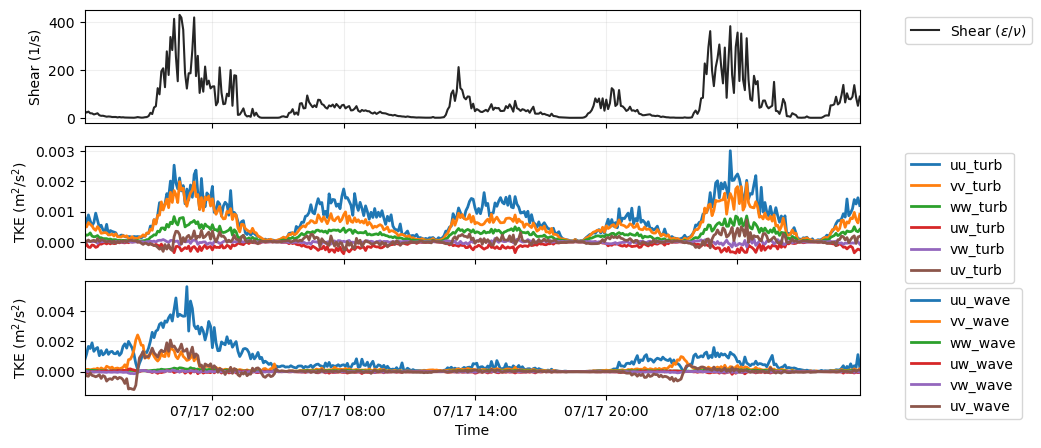

In [ ]:
import pandas as pd 

adv = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/enkf_sediment/processed_adv_data.csv", parse_dates=['time'], index_col='time')
adv.dropna(inplace=True, how='all')
# Apply moving average
adv_shear = adv[['shear']].copy()
smoothed= adv_shear.rolling(window=500, center=True).mean()
# adv['smoothed_shear'] = smoothed['shear']

adv_shear['seconds'] = (adv_shear.index - adv_shear.index[0]).total_seconds()

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), sharex=True, sharey=False)
ax = axs[0]
ax.plot(adv.index, adv_shear.shear, color='k', alpha=0.85, label=r"Shear ($\epsilon/\nu$)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


print(adv.columns)
ax = axs[1]
for turb in ['uu_turb', 'vv_turb', 'ww_turb', 'uw_turb', 'vw_turb',
       'uv_turb']:
    ax.plot(adv.index, adv[turb], label=turb, linewidth=2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax = axs[2]
for turb in ['uu_wave', 'vv_wave', 'ww_wave', 'uw_wave', 'vw_wave',
       'uv_wave']:
    ax.plot(adv.index, adv[turb], label=turb, linewidth=2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
format_date_ax(ax, int=6)
ax.set_xlabel("Time")

axs[0].set_ylabel("Shear (1/s)")
axs[1].set_ylabel("TKE (m$^2$/s$^2$)")
axs[2].set_ylabel("TKE (m$^2$/s$^2$)")

for ax in axs:
    ax.grid(alpha=0.2)
    ax.set_xlim(adv.index[0], adv.index[-1])
    # adv_shear.to_csv("adv_shear_4_model.csv")

In [ ]:
# Load in ADCP data
adcp = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)

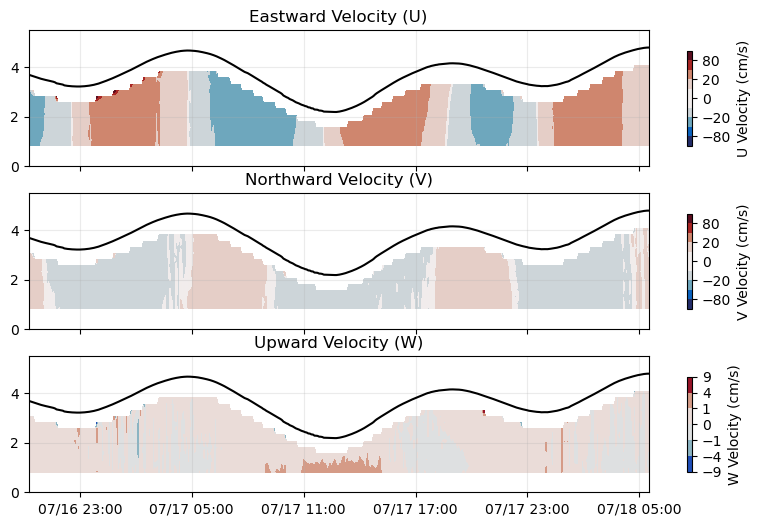

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

low, high = 0, 400
rtime = adcp.time.values[low:high]

offset= 3.537306921274909


axs[0].set_xlim(rtime[0], rtime[-1])
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
z = adcp.depth.values
h = axs[0].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Eastward Velocity (U)')

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


depths =  np.squeeze(adcp.P_1.values[low:high]) #+ 0.41

axs[0].plot(rtime, depths, color='k', label='Depth')
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[2].plot(rtime, depths, color='k', label='Depth')

velocity = np.squeeze(adcp.v_1206)
h = axs[1].contourf(rtime, -z + offset, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)

plt.colorbar(h, label='V Velocity (cm/s)', shrink=0.7)
axs[1].set_title('Northward Velocity (V)')

vmin, vmax = -10, 10
velocity = np.squeeze(adcp.w_1204)

levels = [-9, -4, -1, 0, 1, 4, 9]
h = axs[2].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

for ax in axs:
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=6)
    ax.set_ylim(0, 5.5)


In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=False, constrained_layout=True)

low, high = 0, 900
rtime = adcp.time.values[low:high]

#                                 # blanking distance         
depths =  np.squeeze(adcp.P_1.values[low:high])  

levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
velocity = velocity[low:high,:].T
z = adcp.depth.values
h = axs[0].contourf(rtime, offset-z, velocity, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('ADCP (u, eastward)')


model_time = [pd.to_datetime(rtime[0]) + pd.Timedelta(seconds=j) for j in ds.time.values]

axs[1].set_title("Modeled U Velocity (eastward)")
h = axs[1].contourf(model_time, 4-ds.z, ds.U.T*100, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)

plt.colorbar(h, label='shear (1/s)', shrink=0.7)

for ax in axs:
    ax.plot(rtime, depths, color='k', label='Depth')
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=12)
    ax.set_xlim(rtime[0], rtime[-1])
    ax.set_ylim(0, 10)
    ax.set_ylabel('Depth (m)')
# plt.tight_layout()



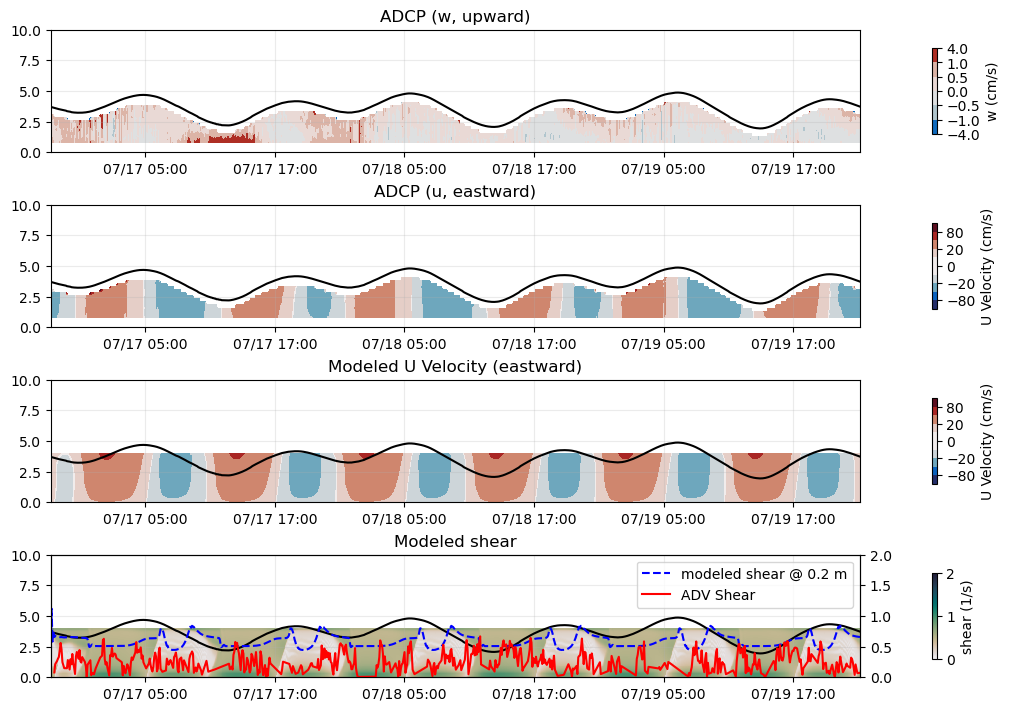

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(10, 7), sharex=False, constrained_layout=True)

low, high = 0, 900
rtime = adcp.time.values[low:high]

#                                 # blanking distance         
depths =  np.squeeze(adcp.P_1.values[low:high])  

levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
velocity = velocity[low:high,:].T
z = adcp.depth.values
h = axs[1].contourf(rtime, offset-z, velocity, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].set_title('ADCP (u, eastward)')


velocity = np.squeeze(adcp.w_1204)
levelsW = [-4, -1, -0.5, 0, 0.5, 1, 4]
h = axs[0].contourf(rtime, offset-z, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levelsW)
plt.colorbar(h, label='w (cm/s)', shrink=0.7)
axs[0].set_title('ADCP (w, upward)')


model_time = [pd.to_datetime(rtime[0]) + pd.Timedelta(seconds=j) for j in ds.time.values]

axs[2].set_title("Modeled U Velocity (eastward)")
h = axs[2].contourf(model_time, 4-ds.z, ds.U.T*100, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)

axs[3].set_title("Modeled shear")
shear = np.sqrt((ds.Q2 /ds.Kz)) 
ax2 = axs[3].twinx()
ax2.plot(model_time, shear.sel(z=0.1, method='nearest').values, '--', color='b', label='modeled shear @ 0.2 m')
ax2.set_ylim(0, 2)

# adv_shear = adv.shear.dropna()
# ax2.plot(adv_shear/10, color='r', label='ADV Shear')
# ax2.legend()
# h = axs[3].pcolormesh(model_time, 4-ds.z, shear.T, cmap=cmo.cm.rain, vmin=0, vmax=2)
# ax2.set_ylabel('shear (1/s)')
# h = axs[3].pcolormesh(model_time, 4-ds.z, ds.C.T, cmap=cmo.cm.rain, vmin=20, vmax=25)

# h = axs[3].pcolormesh(model_time, ds.z, np.log(ds.Q2.T), cmap=cmo.cm.rain, vmin=-8, vmax=-2)
plt.colorbar(h, label='shear (1/s)', shrink=0.7)

for ax in axs:
    ax.plot(rtime, depths, color='k', label='Depth')
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=12)
    ax.set_xlim(rtime[0], rtime[-1])
    ax.set_ylim(0, 10)
    ax.set_ylabel('Depth (m)')
# plt.tight_layout()



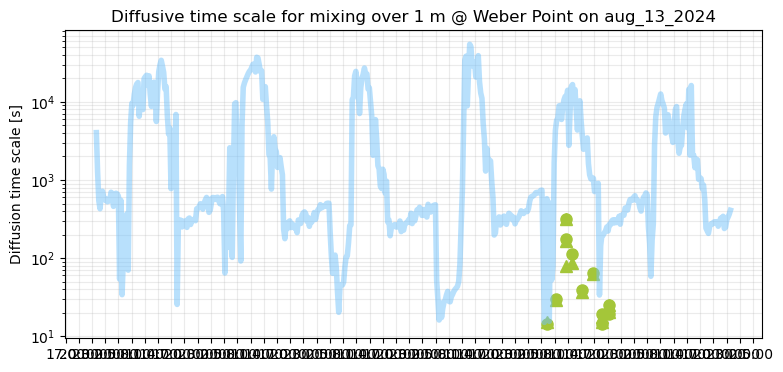

In [ ]:
fig2 = plt.figure(figsize=(9,4))
ax2 = plt.gca()
ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")

# ax2.hlines(1/(diatom), t[0], t[-1], color=colors[2], label="1.4e-5 m/s", linestyle="--")
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(alpha=0.25, which="both")
# ax2.set_xlim(dates[175], dates[220])
ax2.set_yscale('log')
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_title("Diffusive time scale for mixing over 1 m @ Weber Point on %s" % date)
fig.savefig("aug_27.png")